In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display all columns
pd.set_option('display.max_columns', None)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [3]:
df = pd.read_csv("../data/E-commerece sales data 2024.csv")

In [4]:
df.head()

,user id,product id,Interaction type,Time stamp,Unnamed: 4
0,1.0,4c69b61db1fc16e7013b43fc926e502d,purchase,10/10/2023 8:00,NaN
1,2.0,66d49bbed043f5be260fa9f7fbff5957,view,11/10/2023 8:00,NaN
2,3.0,2c55cae269aebf53838484b0d7dd931a,like,12/10/2023 8:00,NaN
3,4.0,18018b6bc416dab347b1b7db79994afa,view,13/10/2023 8:00,NaN
4,5.0,e04b990e95bf73bbe6a3fa09785d7cd0,like,14/10/2023 8:00,NaN


In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3294 entries, 0 to 3293
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user id           2999 non-null   float64
 1   product id        2999 non-null   str    
 2   Interaction type  2871 non-null   str    
 3   Time stamp        2999 non-null   str    
 4   Unnamed: 4        0 non-null      float64
dtypes: float64(2), str(3)
memory usage: 128.8 KB


In [37]:
df.describe(include='all')

,user id,product id,Interaction type,Time stamp,Unnamed: 4
count,2999.000000,2999,2871,2999,0.0
unique,NaN,2999,3,366,NaN
top,NaN,4c69b61db1fc16e7013b43fc926e502d,like,10/10/2023 8:00,NaN
freq,NaN,1,1145,21,NaN
mean,1500.000000,NaN,NaN,NaN,NaN
std,865.881054,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN
25%,750.500000,NaN,NaN,NaN,NaN
50%,1500.000000,NaN,NaN,NaN,NaN
75%,2249.500000,NaN,NaN,NaN,NaN


In [38]:
df.isnull().sum()

user id              295
product id           295
Interaction type     423
Time stamp           295
Unnamed: 4          3294
dtype: int64

In [39]:
df.duplicated().sum()

np.int64(294)

In [40]:
# Create a copy of the original dataset
clean_df = df.copy()

In [41]:
clean_df.drop(columns=['Unnamed: 4'], inplace=True)

In [42]:
clean_df.drop_duplicates(inplace=True)

In [43]:
clean_df.duplicated().sum()

np.int64(0)

In [44]:
clean_df.dropna(inplace=True)

In [45]:
clean_df.isnull().sum()

user id             0
product id          0
Interaction type    0
Time stamp          0
dtype: int64

In [46]:
clean_df['user id'] = clean_df['user id'].astype(int)

In [47]:
clean_df['Time stamp'] = pd.to_datetime(clean_df['Time stamp'])

ValueError: time data "13/10/2023 8:00" doesn't match format "%m/%d/%Y %H:%M". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [48]:
clean_df['Time stamp'] = pd.to_datetime(
    clean_df['Time stamp'],
    dayfirst=True
)

In [49]:
clean_df.info()

<class 'pandas.DataFrame'>
Index: 2871 entries, 0 to 2998
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user id           2871 non-null   int64         
 1   product id        2871 non-null   str           
 2   Interaction type  2871 non-null   str           
 3   Time stamp        2871 non-null   datetime64[us]
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 112.1 KB


In [50]:
clean_df.head()

,user id,product id,Interaction type,Time stamp
0,1,4c69b61db1fc16e7013b43fc926e502d,purchase,2023-10-10 08:00:00
1,2,66d49bbed043f5be260fa9f7fbff5957,view,2023-10-11 08:00:00
2,3,2c55cae269aebf53838484b0d7dd931a,like,2023-10-12 08:00:00
3,4,18018b6bc416dab347b1b7db79994afa,view,2023-10-13 08:00:00
4,5,e04b990e95bf73bbe6a3fa09785d7cd0,like,2023-10-14 08:00:00


In [52]:
clean_df['Date'] = clean_df['Time stamp'].dt.date

In [53]:
clean_df['Year'] = clean_df['Time stamp'].dt.year

In [54]:
clean_df['Month'] = clean_df['Time stamp'].dt.month

In [55]:
clean_df['Month Name'] = clean_df['Time stamp'].dt.month_name()

In [56]:
clean_df['Day'] = clean_df['Time stamp'].dt.day

In [57]:
clean_df['Day Name'] = clean_df['Time stamp'].dt.day_name()

In [58]:
clean_df['Hour'] = clean_df['Time stamp'].dt.hour

In [59]:
clean_df.head()

,user id,product id,Interaction type,Time stamp,Date,Year,Month,Month Name,Day,Day Name,Hour
0,1,4c69b61db1fc16e7013b43fc926e502d,purchase,2023-10-10 08:00:00,2023-10-10,2023,10,October,10,Tuesday,8
1,2,66d49bbed043f5be260fa9f7fbff5957,view,2023-10-11 08:00:00,2023-10-11,2023,10,October,11,Wednesday,8
2,3,2c55cae269aebf53838484b0d7dd931a,like,2023-10-12 08:00:00,2023-10-12,2023,10,October,12,Thursday,8
3,4,18018b6bc416dab347b1b7db79994afa,view,2023-10-13 08:00:00,2023-10-13,2023,10,October,13,Friday,8
4,5,e04b990e95bf73bbe6a3fa09785d7cd0,like,2023-10-14 08:00:00,2023-10-14,2023,10,October,14,Saturday,8


In [60]:
clean_df.info()

<class 'pandas.DataFrame'>
Index: 2871 entries, 0 to 2998
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user id           2871 non-null   int64         
 1   product id        2871 non-null   str           
 2   Interaction type  2871 non-null   str           
 3   Time stamp        2871 non-null   datetime64[us]
 4   Date              2871 non-null   object        
 5   Year              2871 non-null   int32         
 6   Month             2871 non-null   int32         
 7   Month Name        2871 non-null   str           
 8   Day               2871 non-null   int32         
 9   Day Name          2871 non-null   str           
 10  Hour              2871 non-null   int32         
dtypes: datetime64[us](1), int32(4), int64(1), object(1), str(4)
memory usage: 224.3+ KB


In [ ]:
# Business Question 1
#How many unique users and products exist in the dataset?

In [ ]:
print("Total Records:", len(clean_df))
print("Unique Users:", clean_df['user id'].nunique())
print("Unique Products:", clean_df['product id'].nunique())

Total Records: 2871
Unique Users: 2871
Unique Products: 2871


In [ ]:
#What is the distribution of interaction types?

In [ ]:
clean_df['Interaction type'].value_counts()

Interaction type
like        1145
view         871
purchase     855
Name: count, dtype: int64

In [ ]:
#Percentage of each interaction

In [ ]:
interaction_percent = (
    clean_df['Interaction type']
    .value_counts(normalize=True) * 100
).round(2)

interaction_percent

Interaction type
like        39.88
view        30.34
purchase    29.78
Name: proportion, dtype: float64

In [ ]:
#First Visualization

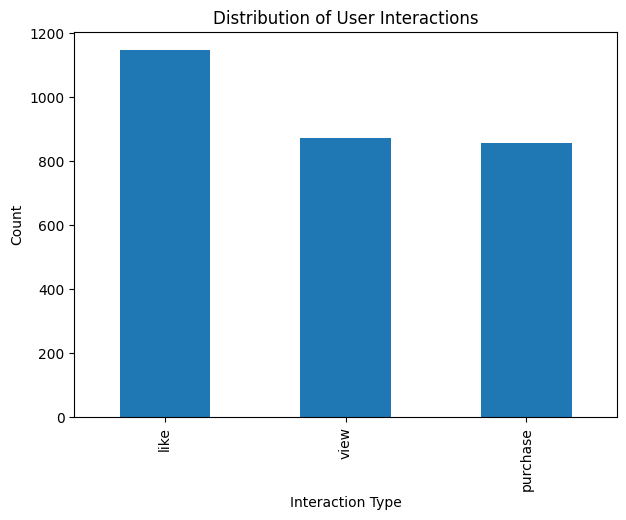

In [ ]:
interaction_counts = clean_df['Interaction type'].value_counts()

plt.figure(figsize=(7,5))

interaction_counts.plot(kind='bar')

plt.title("Distribution of User Interactions")

plt.xlabel("Interaction Type")

plt.ylabel("Count")

plt.show()

In [ ]:
### 📊 Business Insight

#- **Like** is the most frequent interaction, indicating that users are actively engaging with products.
#- **Views** and **Purchases** occur less frequently than likes.
#- The business should analyze why many liked products are not converting into purchases and consider strategies such as personalized recommendations, discounts, or reminder notifications to improve conversion.

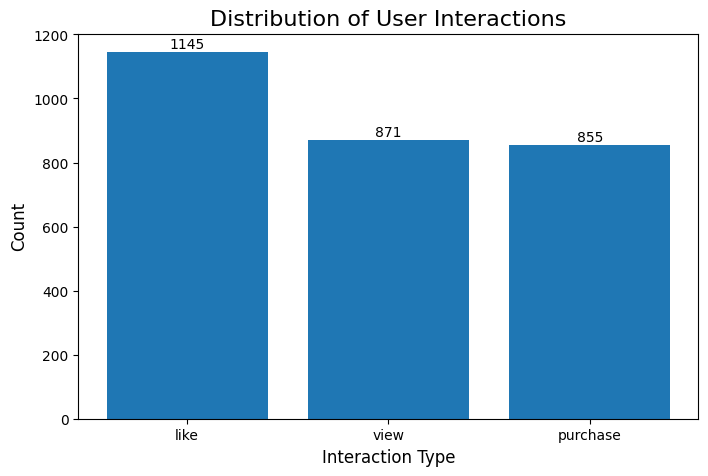

In [ ]:
interaction_counts = clean_df['Interaction type'].value_counts()

plt.figure(figsize=(8,5))

bars = plt.bar(interaction_counts.index, interaction_counts.values)

plt.title("Distribution of User Interactions", fontsize=16)
plt.xlabel("Interaction Type", fontsize=12)
plt.ylabel("Count", fontsize=12)

# Display values on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 10,
        f"{int(height)}",
        ha='center'
    )

plt.show()

In [ ]:
# Business Question 2

# Which products have the highest number of user interactions?

In [ ]:
top_products = (
    clean_df['product id']
    .value_counts()
    .head(10)
)

top_products

product id
4c69b61db1fc16e7013b43fc926e502d    1
66d49bbed043f5be260fa9f7fbff5957    1
2c55cae269aebf53838484b0d7dd931a    1
18018b6bc416dab347b1b7db79994afa    1
e04b990e95bf73bbe6a3fa09785d7cd0    1
f8c32a45e507a177992973cf0d46d20c    1
40d3cd16b41970ae6872e914aecf2c8e    1
bc178f33a04dbccefa95b165f8b56830    1
cc2083338a16c3fe2f7895289d2e98fe    1
69828c5570dcdbd1609216d33fbad0db    1
Name: count, dtype: int64

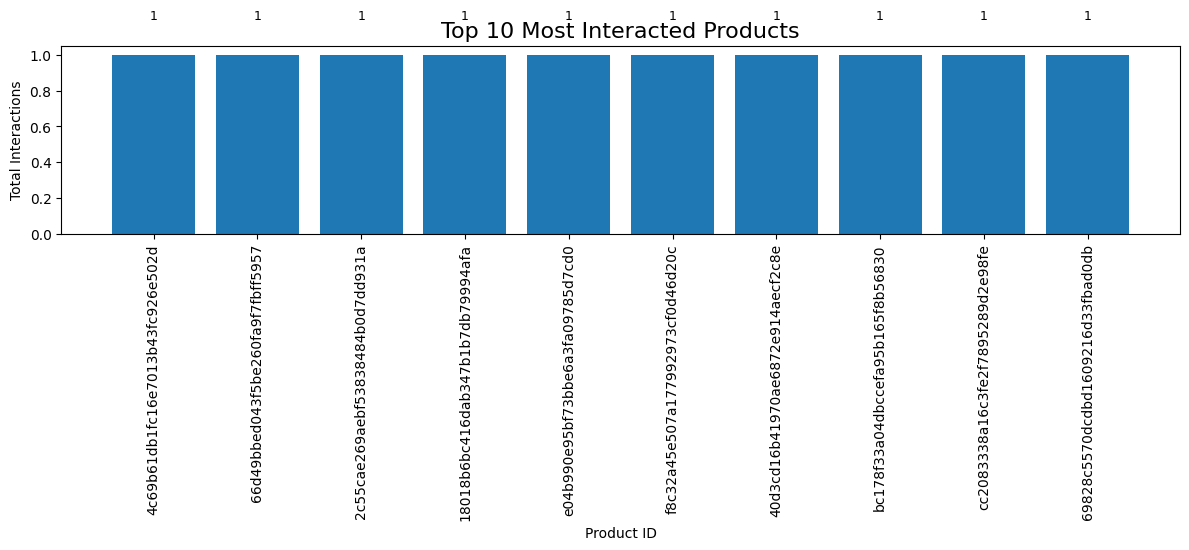

In [ ]:
plt.figure(figsize=(12,6))

bars = plt.bar(top_products.index, top_products.values)

plt.title("Top 10 Most Interacted Products", fontsize=16)

plt.xlabel("Product ID")

plt.ylabel("Total Interactions")

plt.xticks(rotation=90)

# Display values
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.2,
        int(bar.get_height()),
        ha='center',
        fontsize=9
    )

plt.tight_layout()

plt.show()

In [ ]:
### 📊 Business Insight

#- The chart identifies the products with the highest customer engagement.
#- Highly interacted products may represent popular or trending items.
#- These products can be prioritized for promotions, inventory planning, or recommendation systems.

In [ ]:
# Business Question 3
# Which users are the most active?

In [ ]:
top_users = (
    clean_df['user id']
    .value_counts()
    .head(10)
)

top_users

user id
1     1
2     1
3     1
4     1
5     1
6     1
7     1
8     1
9     1
10    1
Name: count, dtype: int64

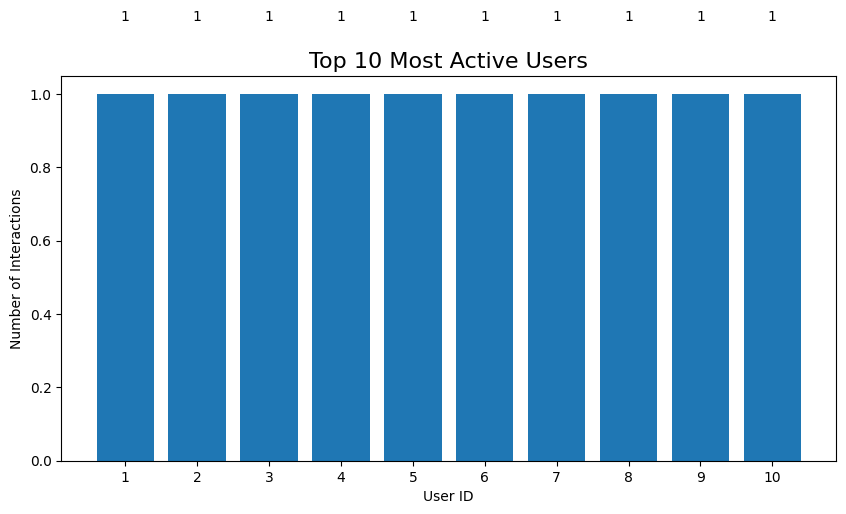

In [ ]:
plt.figure(figsize=(10,5))

bars = plt.bar(top_users.index.astype(str), top_users.values)

plt.title("Top 10 Most Active Users", fontsize=16)

plt.xlabel("User ID")

plt.ylabel("Number of Interactions")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.2,
        int(bar.get_height()),
        ha='center'
    )

plt.show()

In [ ]:
###  Business Insight

#- These users interact with products more frequently than others.
#- They may represent loyal customers or highly engaged visitors.
# The business can target them with loyalty programs or personalized offers.

In [ ]:
# Business Question 4
# Which month had the highest activity?

In [ ]:
monthly_activity = (
    clean_df['Month Name']
    .value_counts()
)

monthly_activity

Month Name
December     576
November     565
January      415
October      409
February     135
May          124
March        122
June         120
April        118
July         106
August        93
September     88
Name: count, dtype: int64

In [ ]:
#Business Question 5
# Which day of the week has the highest user activity?

In [ ]:
day_activity = clean_df['Day Name'].value_counts()

day_activity

Day Name
Thursday     422
Wednesday    421
Tuesday      415
Sunday       415
Friday       401
Saturday     400
Monday       397
Name: count, dtype: int64

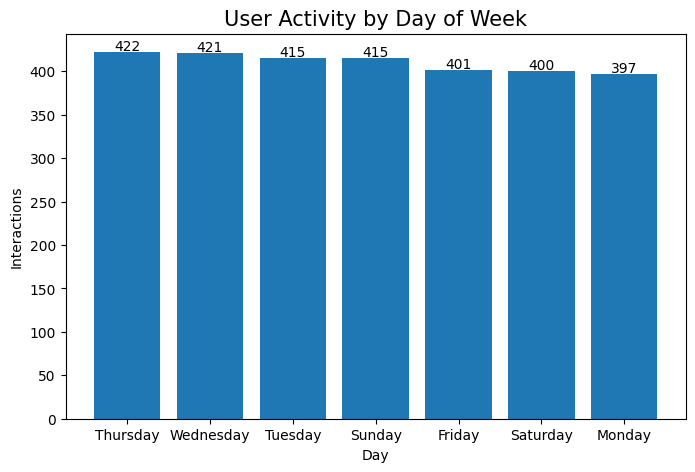

In [ ]:
plt.figure(figsize=(8,5))

bars = plt.bar(day_activity.index, day_activity.values)

plt.title("User Activity by Day of Week", fontsize=15)
plt.xlabel("Day")
plt.ylabel("Interactions")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2,
        int(bar.get_height()),
        ha='center'
    )

plt.show()

In [ ]:
### Business Insight

#- This chart highlights which weekdays have the highest customer engagement.
#- The business can schedule promotions and campaigns on high-traffic days.

In [ ]:
#Business Question 6
#At what hour are users most active?

In [ ]:
hourly_activity = clean_df['Hour'].value_counts().sort_index()

hourly_activity

Hour
0       17
8     1470
10    1384
Name: count, dtype: int64

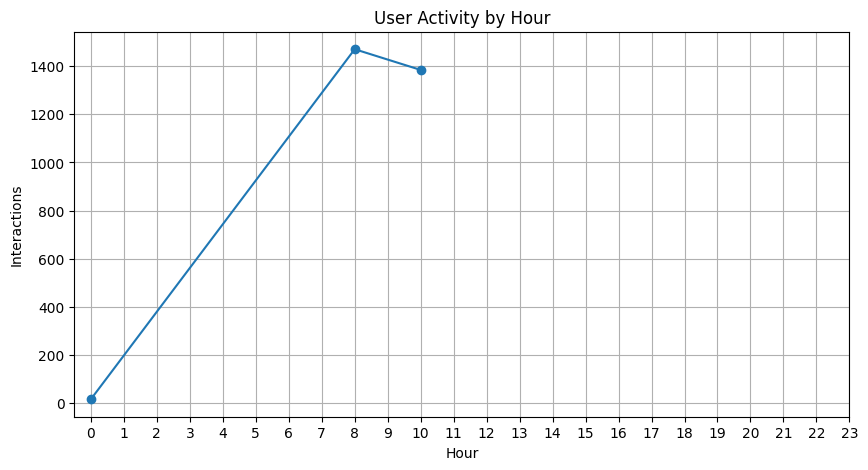

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    hourly_activity.index,
    hourly_activity.values,
    marker='o'
)

plt.title("User Activity by Hour")

plt.xlabel("Hour")

plt.ylabel("Interactions")

plt.xticks(range(0,24))

plt.grid(True)

plt.show()

In [ ]:
### Business Insight

#- This analysis identifies the hours when users are most active.
#- Marketing campaigns and notifications can be scheduled during peak engagement hours.

In [ ]:
#Business Question 7
#Which products are actually getting purchased the most?

In [ ]:
purchased_products = (
    clean_df[clean_df['Interaction type'] == 'purchase']
    ['product id']
    .value_counts()
    .head(10)
)

purchased_products

product id
4c69b61db1fc16e7013b43fc926e502d    1
40d3cd16b41970ae6872e914aecf2c8e    1
69828c5570dcdbd1609216d33fbad0db    1
7b0746d8afc8462ba17f8a763d9d5f1e    1
d82015ffbf4cd54b0edfb890002971f3    1
fd71391871b94ead84733bc272dd5886    1
a84f14dd0114d78f178b16f093cab0e0    1
326ebcfaa8d5204b634b5648e88e2fe4    1
c15e7efbe14b9bbcb8b7fe31f9818021    1
5bb4a9aa52085ada20006d166b1e2f87    1
Name: count, dtype: int64

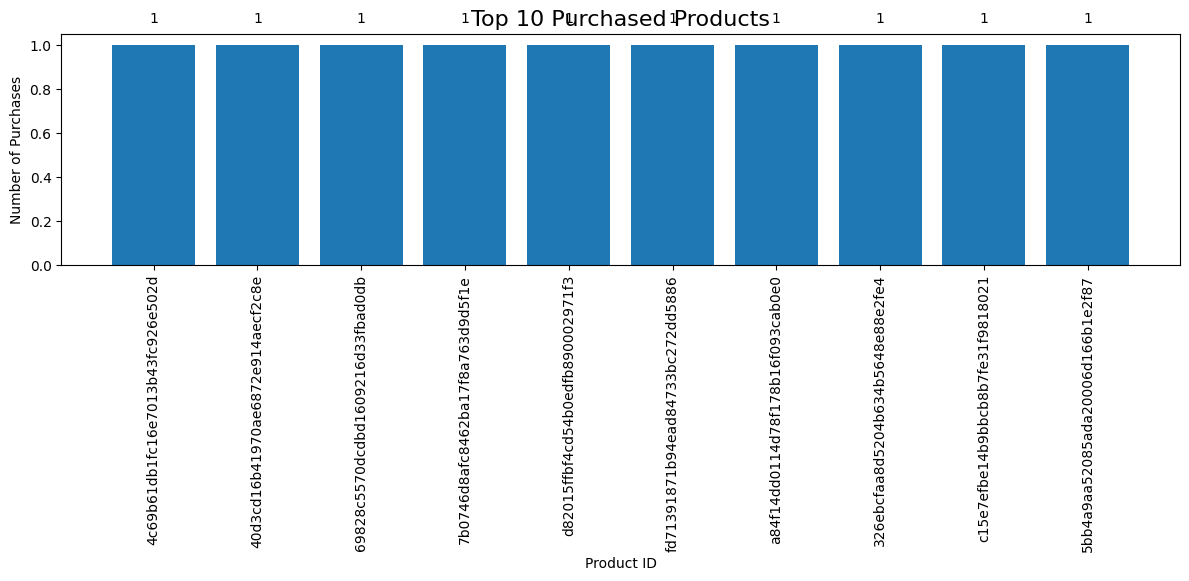

In [ ]:
plt.figure(figsize=(12,6))

bars = plt.bar(
    purchased_products.index,
    purchased_products.values
)

plt.title("Top 10 Purchased Products", fontsize=16)

plt.xlabel("Product ID")

plt.ylabel("Number of Purchases")

plt.xticks(rotation=90)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.1,
        int(bar.get_height()),
        ha='center'
    )

plt.tight_layout()

plt.show()

In [ ]:
### Business Insight

#- These products generate the highest purchase activity.
#- They should be prioritized in inventory planning.
#- They are ideal candidates for promotional campaigns.

In [ ]:
#Business Question 8
#Which products receive the most Likes?

In [ ]:
liked_products = (
    clean_df[clean_df['Interaction type'] == 'like']
    ['product id']
    .value_counts()
    .head(10)
)

liked_products

product id
2c55cae269aebf53838484b0d7dd931a    1
e04b990e95bf73bbe6a3fa09785d7cd0    1
f8c32a45e507a177992973cf0d46d20c    1
cc2083338a16c3fe2f7895289d2e98fe    1
615ba903c134f439eaf8cdd1678ceb5c    1
1ecccb43e0f5c0162218371916ffa553    1
d1ac6d805fcdf75f9e00af611dd03ce4    1
4af0833f20a8421788fc04577b0ef1c5    1
89a993dbc079cc3fbe9088c8170b6f99    1
af983053a35fa2a843092369ff3b400b    1
Name: count, dtype: int64

In [ ]:
#Business Question 9
#Which products receive the most Views?

In [ ]:
viewed_products = (
    clean_df[clean_df['Interaction type'] == 'view']
    ['product id']
    .value_counts()
    .head(10)
)

viewed_products

product id
66d49bbed043f5be260fa9f7fbff5957    1
18018b6bc416dab347b1b7db79994afa    1
bc178f33a04dbccefa95b165f8b56830    1
c5f4c94653a3befd8dd16adf2914c04e    1
82c86a4d24dce5e14303033d7b658b78    1
39f1b8a2129315da0288cd058b6b6086    1
f5b9392a03cfae8817307a36411c8b17    1
84fb43b933850dc05e57a162c5ba1702    1
a11d9462309527143094a0f68bce0a58    1
2339c5be505bf647ebff669697c6bc25    1
Name: count, dtype: int64

In [ ]:
#Business Question 10
#What is the overall interaction percentage?

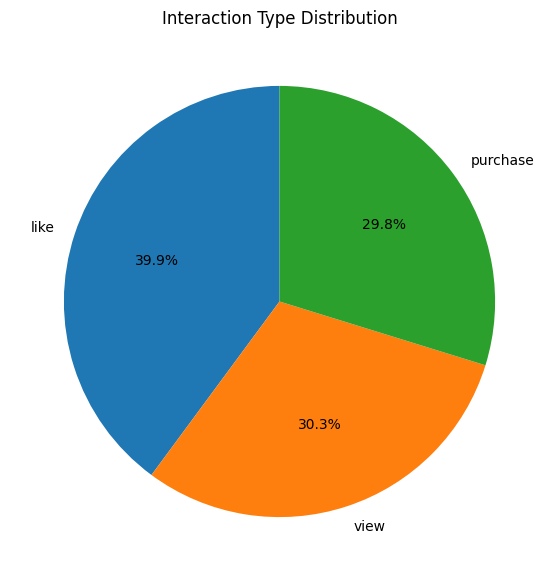

In [ ]:
interaction_counts = clean_df['Interaction type'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    interaction_counts,
    labels=interaction_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Interaction Type Distribution")

plt.show()

In [ ]:
### Business Insight

#- This chart provides a quick overview of customer engagement.
#- Understanding interaction distribution helps identify whether users mostly browse, engage, or purchase products.

In [ ]:
#Business Question 11
#Daily Trend

In [ ]:
daily_activity = (
    clean_df.groupby('Date')
    .size()
)

daily_activity.head()

Date
2022-12-28    18
2022-12-29    18
2022-12-30    18
2022-12-31    18
2023-01-01    34
dtype: int64

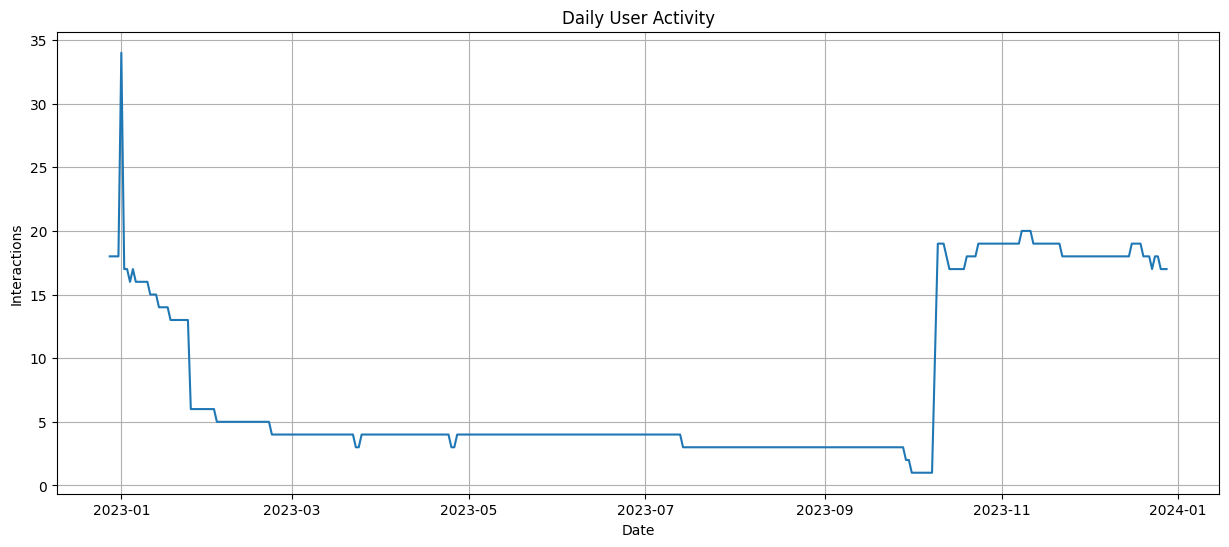

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(
    daily_activity.index,
    daily_activity.values
)

plt.title("Daily User Activity")

plt.xlabel("Date")

plt.ylabel("Interactions")

plt.grid(True)

plt.show()

In [ ]:
# 📌 Final Business Summary

## Key Findings

#- Cleaned the dataset by removing missing values, duplicate records, and unnecessary columns.
#- Created additional date and time features to enable temporal analysis.
#- Identified the distribution of user interactions.
#- Determined the most active users.
#- Identified the most popular products.
#- Analyzed purchase, like, and view behavior.
#- Explored user activity by weekday and hour.
#- Observed daily interaction trends.

## Business Recommendations

#- Promote products with high engagement but low purchase activity.
#- Reward highly active users through loyalty programs.
#- Schedule marketing campaigns during peak activity periods.
#- Monitor interaction trends to improve customer engagement.

In [ ]:
# Conclusion

#This project demonstrates a complete data analysis workflow including data cleaning, feature engineering, exploratory data analysis, visualization, and business insights.

#The analysis helps understand customer behavior and provides recommendations that can support business decision-making.

In [61]:
clean_df.to_csv("../data/cleaned_ecommerce_data.csv", index=False)